C:\Users\daiya\AppData\Local\Temp\ipykernel_27732\958092110.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # グラフを表示する
C:\Users\daiya\AppData\Local\Temp\ipykernel_27732\958092110.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # グラフを表示する


max: 21341.95733249193
min: 0.0


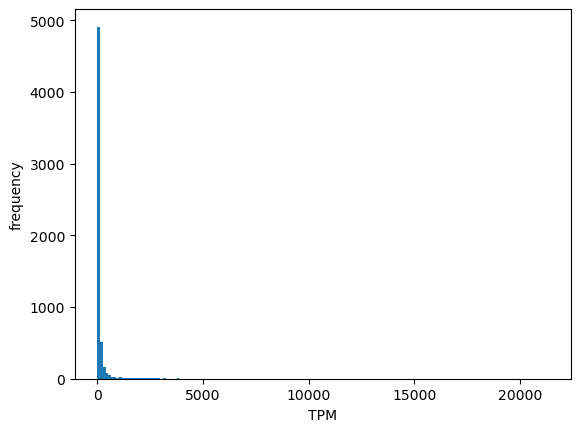

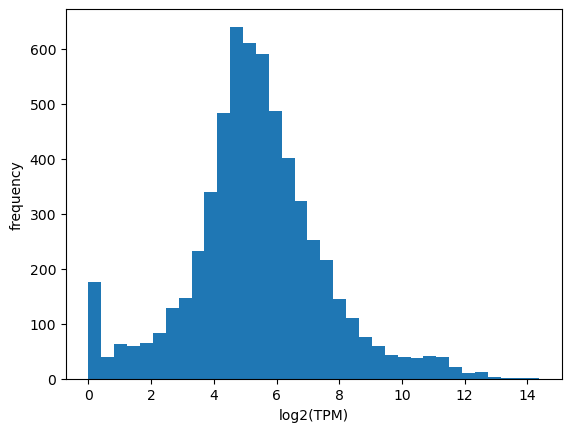

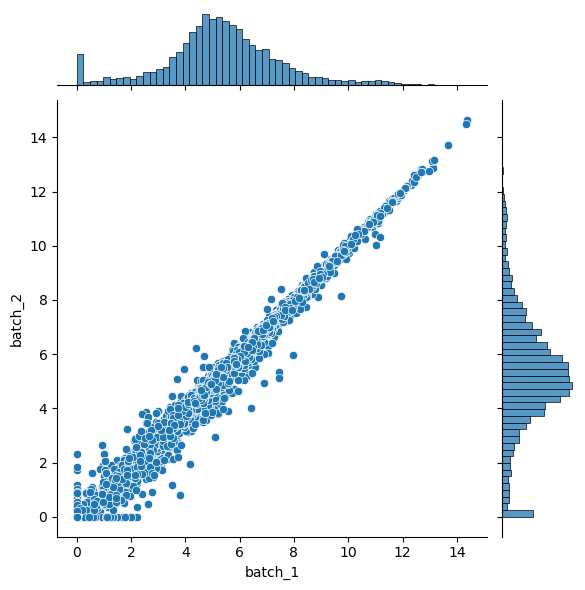

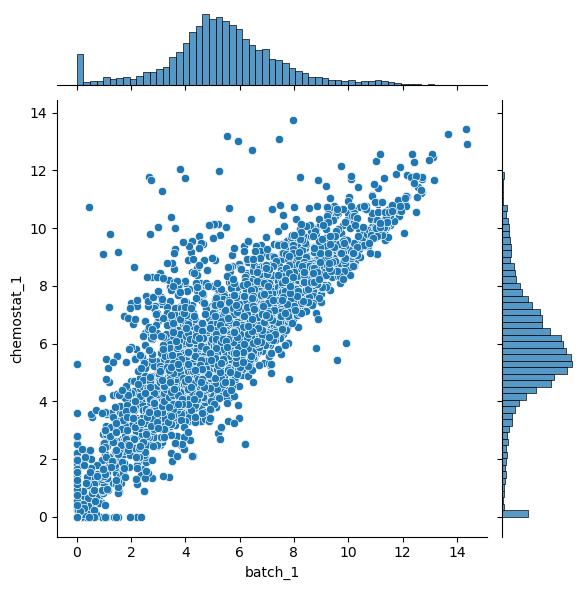

              batch_1   batch_2   batch_3  chemostat_1  chemostat_2  \
batch_1      1.000000  0.991891  0.989675     0.868298     0.855021   
batch_2      0.991891  1.000000  0.994721     0.848379     0.833718   
batch_3      0.989675  0.994721  1.000000     0.843316     0.829421   
chemostat_1  0.868298  0.848379  0.843316     1.000000     0.990472   
chemostat_2  0.855021  0.833718  0.829421     0.990472     1.000000   
chemostat_3  0.859642  0.838742  0.835142     0.990262     0.993528   

             chemostat_3  
batch_1         0.859642  
batch_2         0.838742  
batch_3         0.835142  
chemostat_1     0.990262  
chemostat_2     0.993528  
chemostat_3     1.000000  


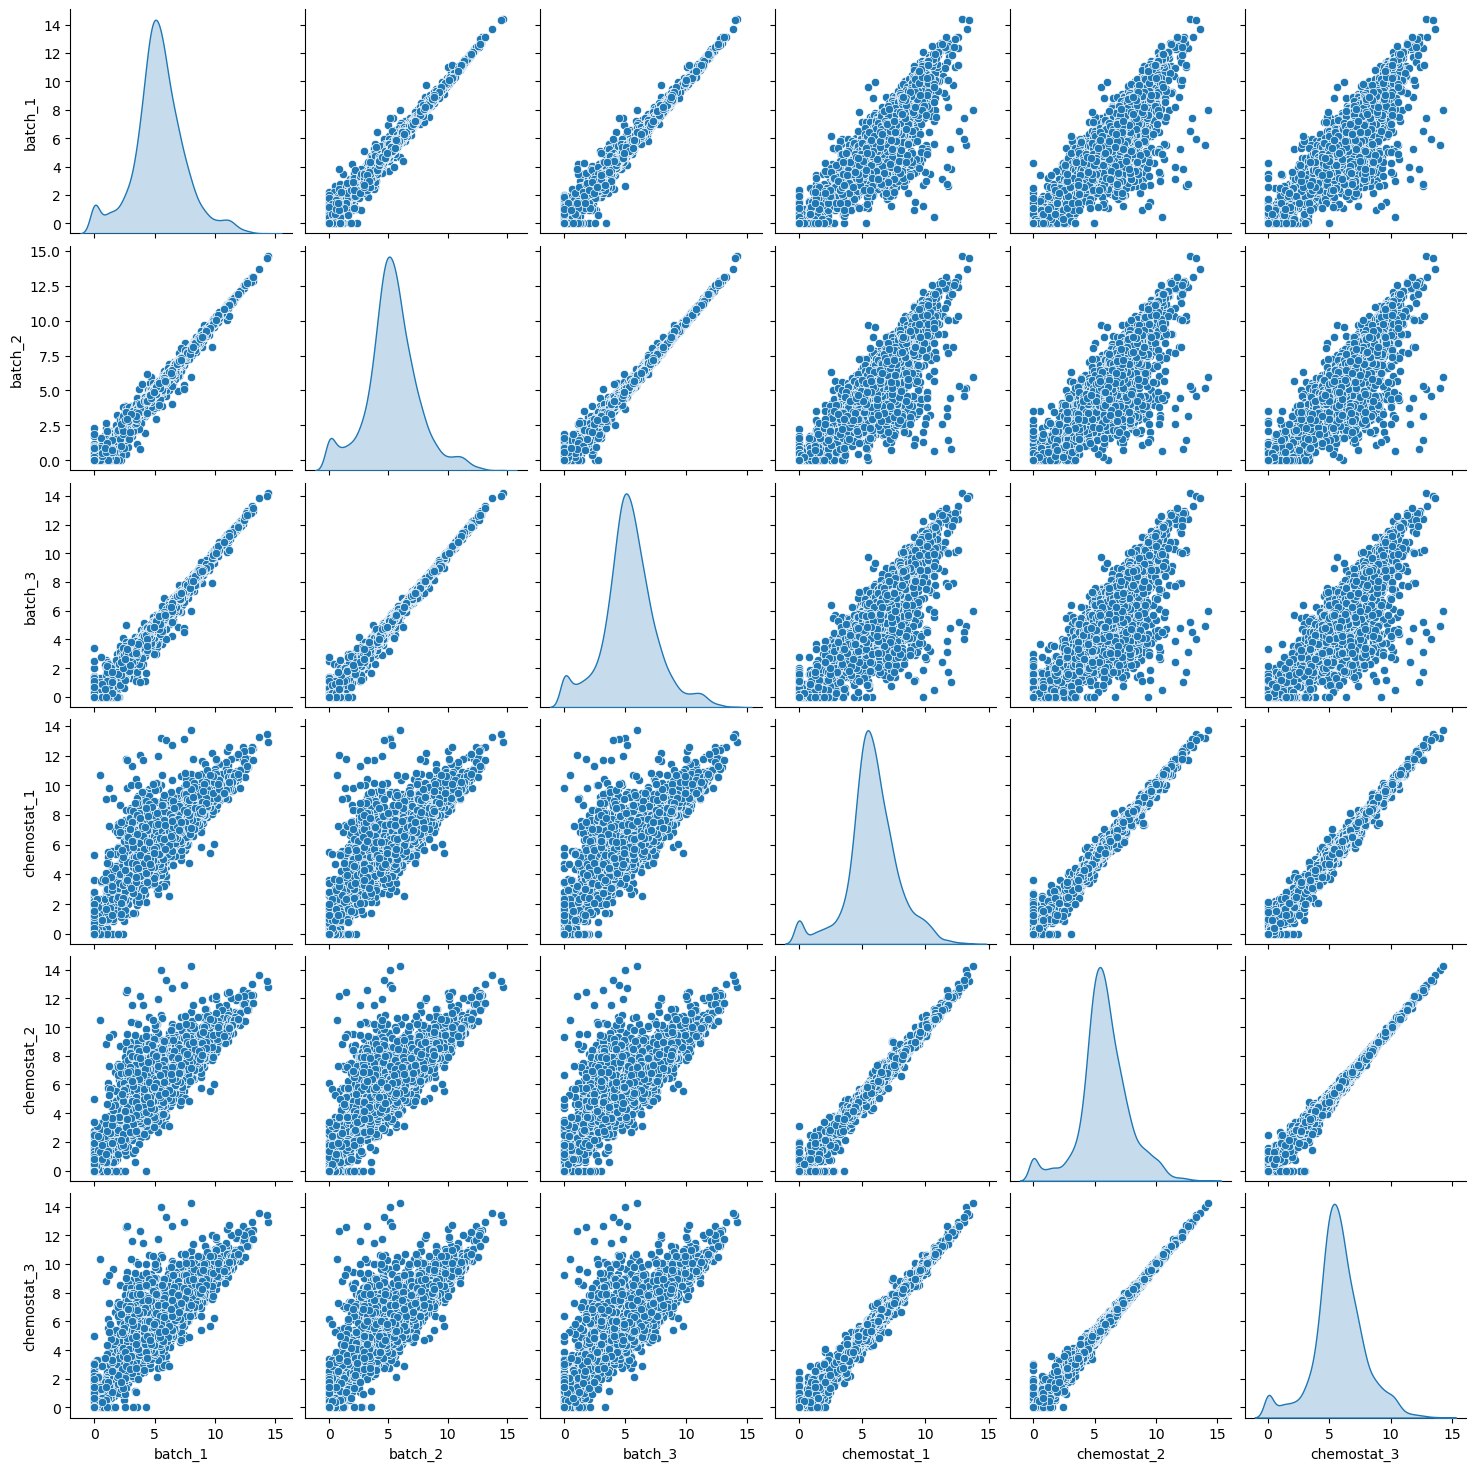

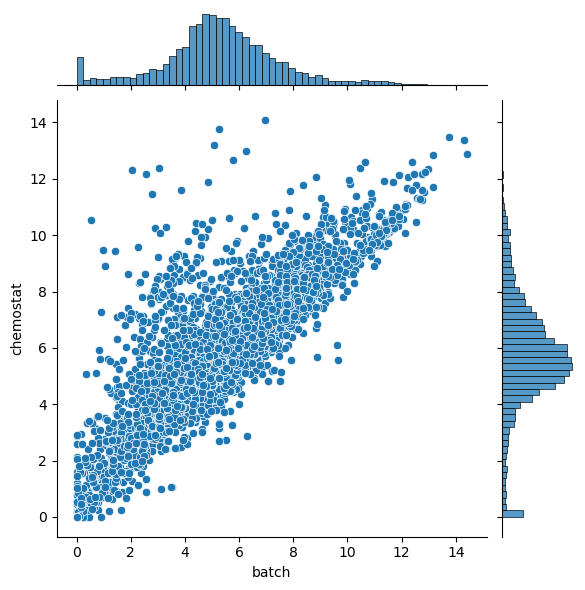

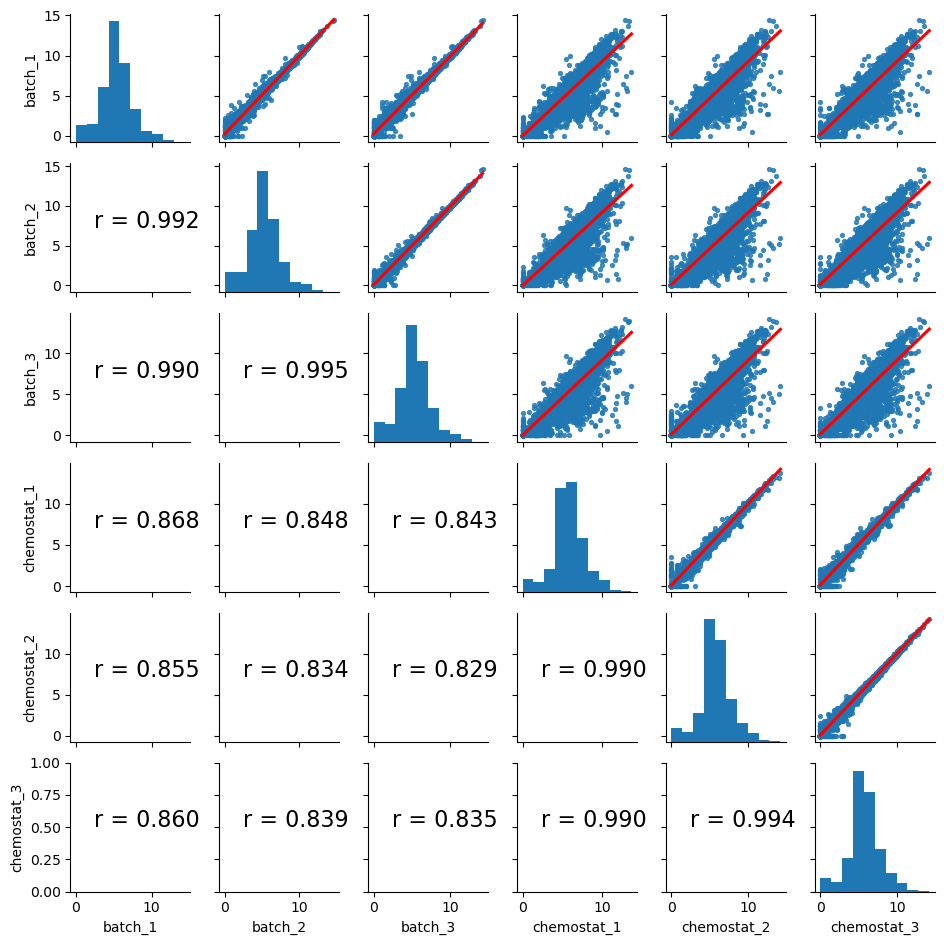

In [17]:
import pandas as pd # データ解析ライブラリpandasを読み込む
import numpy as np # 数値計算ライブラリnumpyを読み込む

# GitHub上のExcelファイル(TPMデータ)を読み込んでデータフレーム(df_tpm)に格納する
df_tpm = pd.read_excel("https://github.com/iwata97/bioinfo/raw/refs/heads/main/TPM_data.xlsx")

# データフレーム全体を表示する
df_tpm

# データフレームの先頭5行を表示して中身を確認する
df_tpm.head()

# "gene"列（遺伝子名）を削除し、数値データのみの変数tpmを作成する
tpm=df_tpm.drop("gene", axis=1)

# 数値データの先頭5行を確認する
tpm.head()

# 0番目の列（batch_1）のデータをすべての行について抽出する
tpm.iloc[:,0]

import matplotlib.pyplot as plt # グラフ描画ライブラリmatplotlibを読み込む

x = tpm.iloc[:, 0] # batch_1のTPMデータを変数xに代入する
fig = plt.figure() # グラフを描くための土台（図）を作成する
ax = fig.add_subplot() # 図の中にグラフを描くための領域（軸）を追加する

# 変数xのヒストグラムを作成する。bins='scott'で階級幅を自動計算する
ax.hist(x, bins='scott') 

ax.set_xlabel('TPM') # X軸のラベルを'TPM'に設定する
ax.set_ylabel('frequency') # Y軸のラベルを'frequency'（頻度）に設定する
fig.show() # グラフを表示する

max_value = x.max() # データxの最大値を取得する
min_value = x.min() # データxの最小値を取得する
print('max:', max_value) # 最大値を表示する
print('min:', min_value) # 最小値を表示する

# TPM値に1.0を足してから2を底とする対数(log2)に変換する（0の対数計算を避けるため）
log_tpm = np.log2(tpm + 1.0)

# 対数変換後のデータの先頭5行を確認する
log_tpm.head()

x = log_tpm.iloc[:, 0] # 対数変換したデータの1列目を変数xに代入する
fig = plt.figure() # 新しいグラフの土台を作成する
ax = fig.add_subplot() # グラフ領域を追加する
ax.hist(x, bins='scott') # 対数変換後のデータのヒストグラムを作成する
ax.set_xlabel('log2(TPM)') # X軸ラベルを'log2(TPM)'に設定する
ax.set_ylabel('frequency') # Y軸ラベルを'frequency'に設定する
fig.show() # グラフを表示する

import seaborn as sns # 統計的グラフ描画ライブラリseabornを読み込む

# batch_1とbatch_2の相関を示す散布図とヒストグラム（ジョイントプロット）を描画する
sns.jointplot(data=log_tpm, x = 'batch_1', y = 'batch_2')
plt.show() # 表示する

# batch_1とchemostat_1のジョイントプロットを描画する
sns.jointplot(data=log_tpm, x = 'batch_1', y = 'chemostat_1')
plt.show() # 表示する

corr = log_tpm.corr() # 各列間の相関係数（ピアソン相関）を計算する
print(corr) # 相関係数の行列を表示する

# 全ての列の組み合わせをグリッド状に並べたペアプロットを作成する。対角線はカーネル密度推定図にする
sns.pairplot(log_tpm, diag_kind='kde') 
plt.show() # 表示する

# batch系（1〜3列目）の平均値を計算し、1を足してlog2変換する
batch_log_tpm_mean = np.log2(tpm.iloc[:, :3].mean(axis=1).values + 1)
# chemostat系（4列目以降）の平均値を計算し、1を足してlog2変換する
chemostat_log_mean = np.log2(tpm.iloc[:, 3:].mean(axis=1).values + 1)

# 計算した平均値をまとめた新しいデータフレームを作成する
log_tpm_lib_mean = pd.DataFrame({'batch': batch_log_tpm_mean,
                                 'chemostat': chemostat_log_mean})

# batch平均とchemostat平均のジョイントプロットを描画する
sns.jointplot(data=log_tpm_lib_mean, x = 'batch', y = 'chemostat')
plt.show() # 表示する

# --- 以下、独自のペアプロット関数を定義するための再インポートと関数定義 ---

import numpy as np
import pandas as pd
from scipy import stats # 統計計算用ライブラリを読み込む
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

# ヒストグラムを描画する関数を定義する。欠損値(NaN)は除外する
def draw_hist(x, **kws):
    plt.hist(x[~np.isnan(x)])

# 相関係数をグラフ上にテキストとして表示する関数を定義する
def corr_func(x, y, **kws):
    # 両方のデータに欠損値がない部分だけを抽出するマスクを作成する
    mask = ~np.logical_or(np.isnan(x), np.isnan(y))
    x, y = x[mask], y[mask]
    # ピアソン相関係数(r)を計算する
    r, _ = stats.pearsonr(x, y)
    ax = plt.gca() # 現在の描画対象（軸）を取得する
    # 相関係数を図の中央付近に表示する
    ax.annotate("r = {:.3f}".format(r),
                xy=(.2, .5),
                xycoords=ax.transAxes,
                size=16)

# オリジナルのペアプロットを描画する関数を定義する
def pairplot(df):
    # 各列の組み合わせでグリッド（PairGrid）を作成する
    g = sns.PairGrid(df, height=1.6, dropna=False)
    # 対角線には上で定義したヒストグラム関数(draw_hist)を適用する
    g.map_diag(draw_hist)
    # 右上(Upper)には回帰直線付きの散布図を描画する
    g.map_upper(sns.regplot, scatter_kws={"s": 8}, line_kws={"color":  "r"})
    # 左下(Lower)には上で定義した相関係数表示関数(corr_func)を適用する
    g.map_lower(corr_func)
    # 定義した関数を呼び出して、実際にグラフを描画する
pairplot(log_tpm)


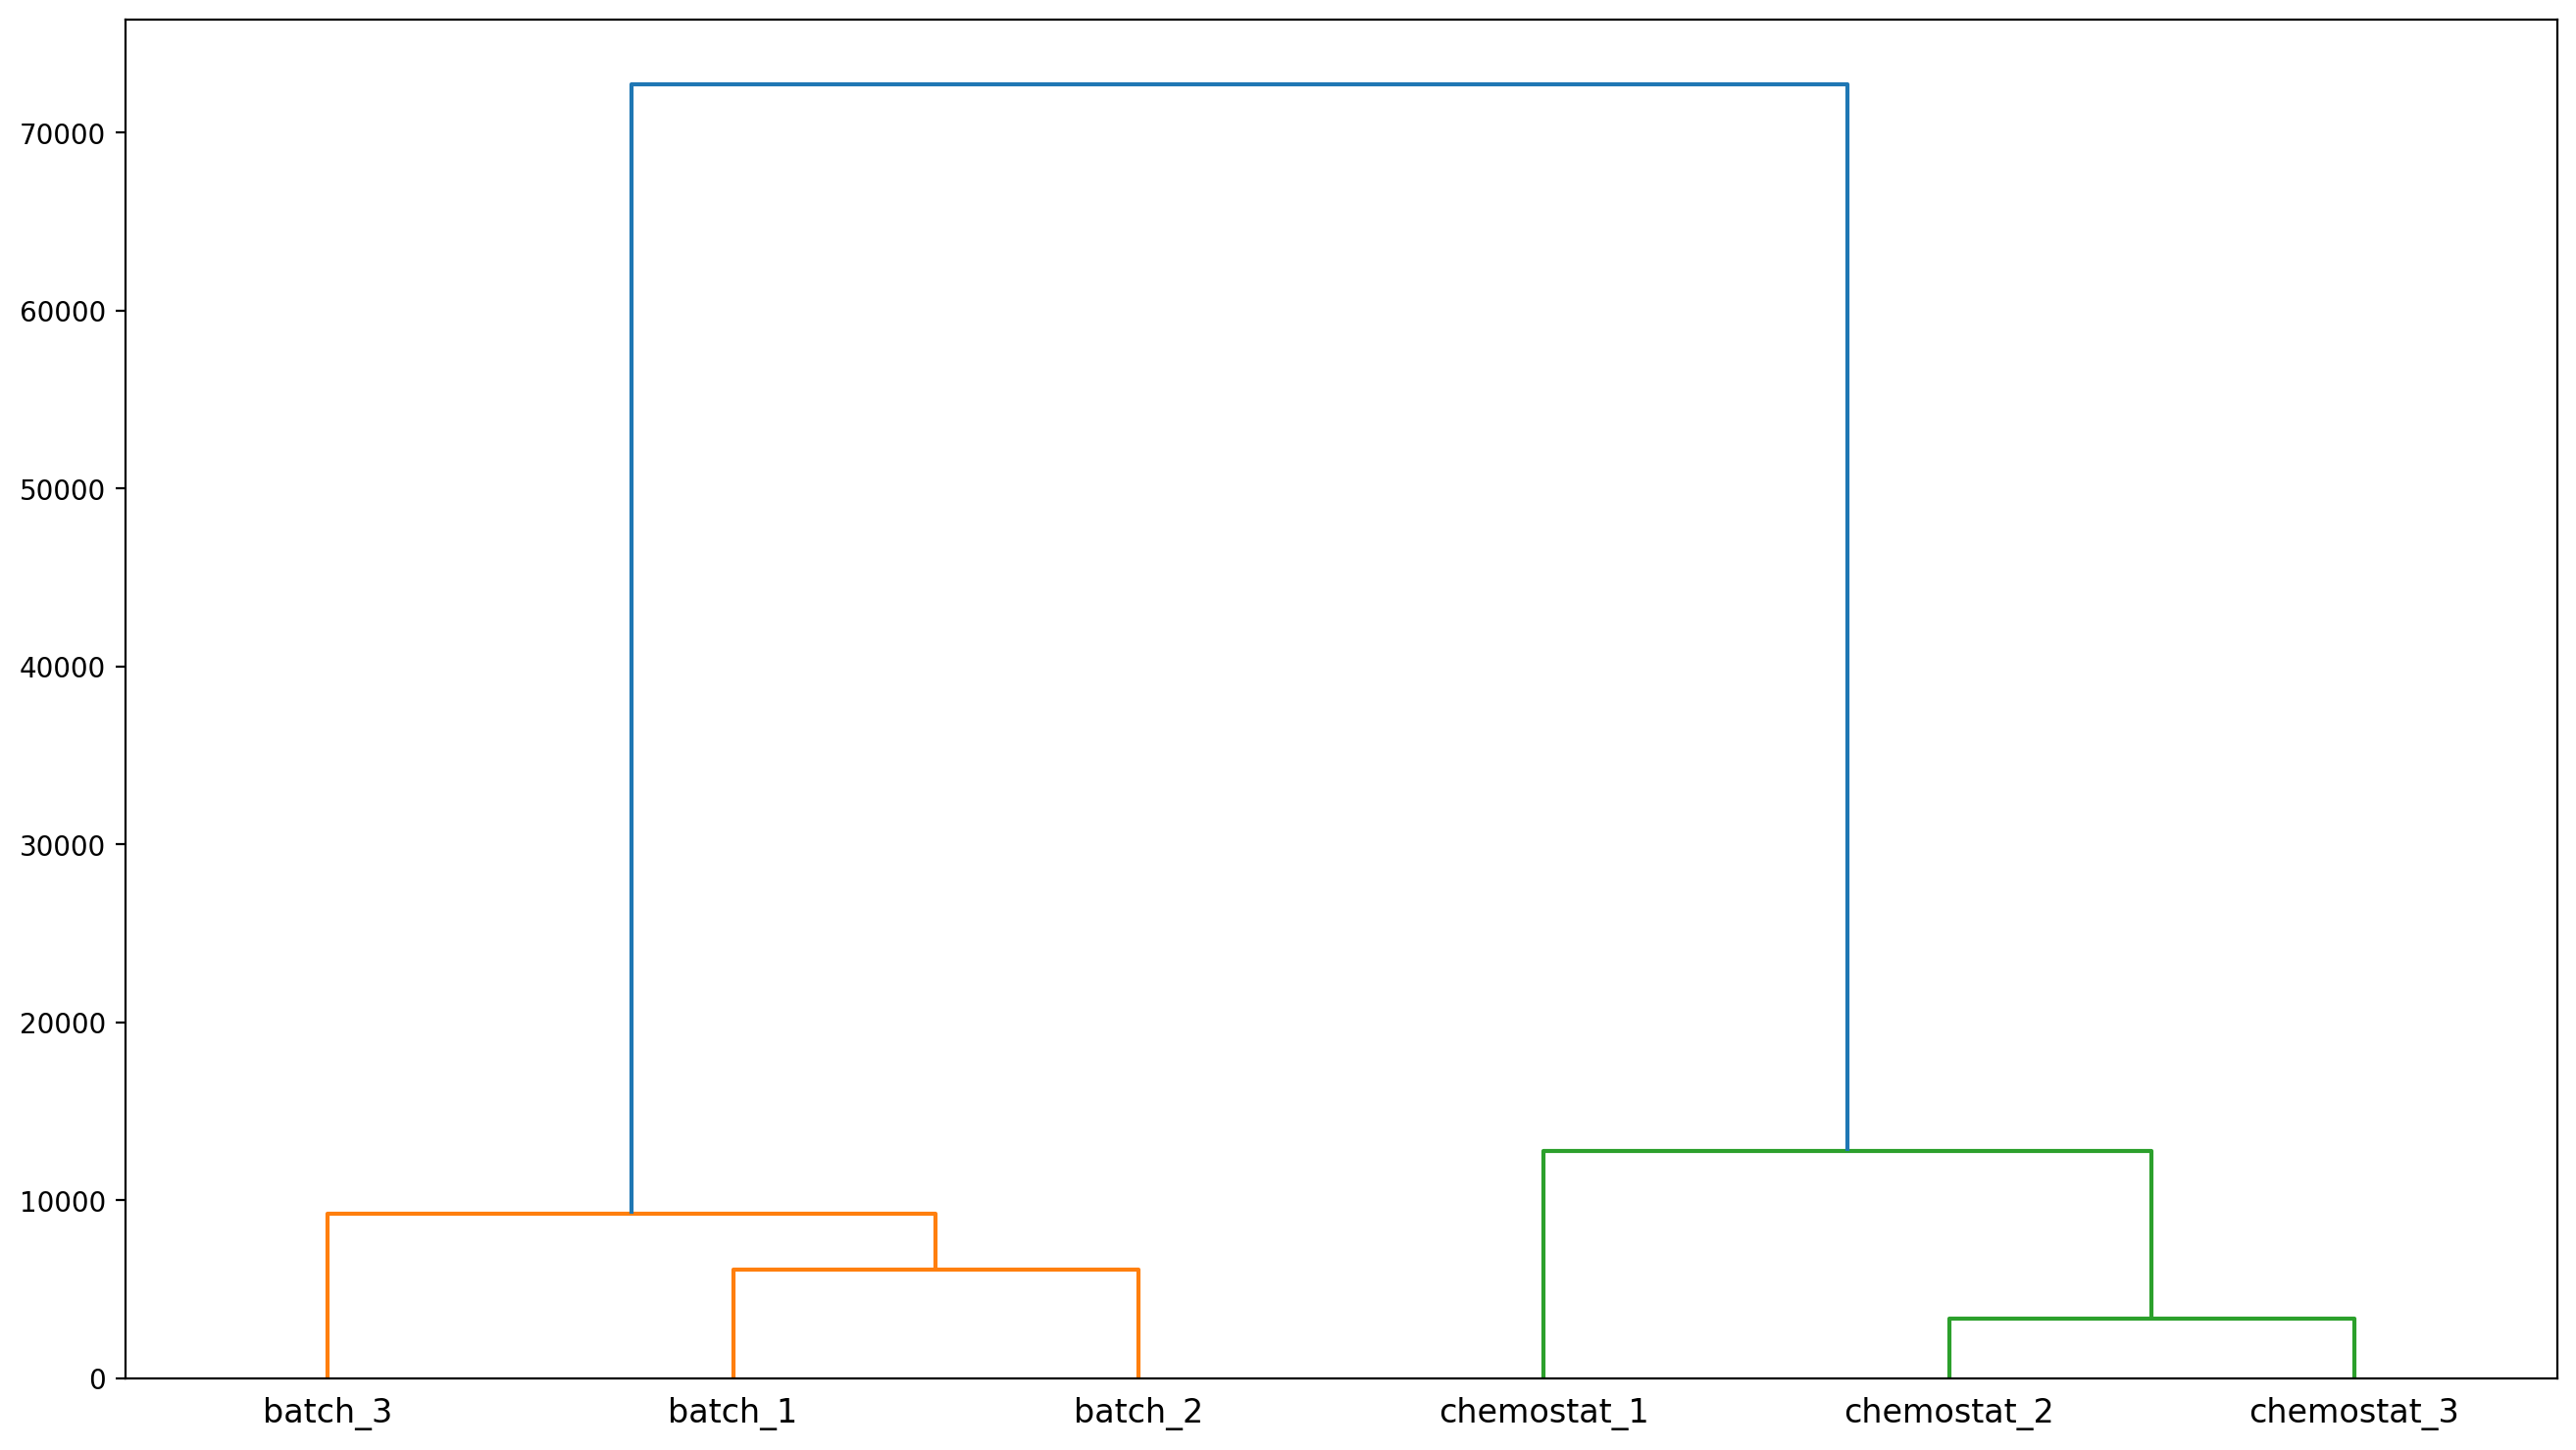

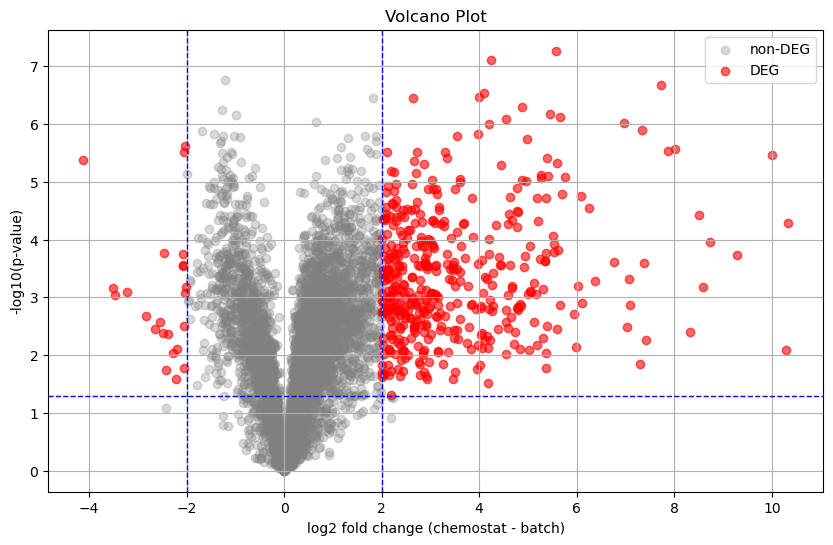

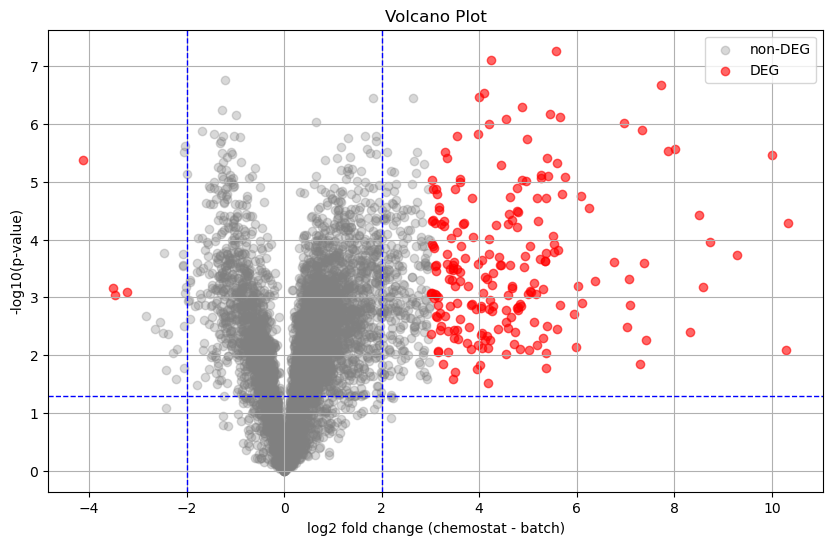

                                                   gene    log2FC  \
1162                                         catalase A  5.571445   
5926                                              Sue1p  4.231303   
4543                         alcohol dehydrogenase ADH2  7.723890   
9                glutamate dehydrogenase (NADP(+)) GDH3  4.089283   
2760                                              Xbp1p  4.004069   
4313                                              Isf1p  4.875161   
3484  bifunctional hydroxyacyl-CoA dehydrogenase/eno...  5.447275   
1993                                              Gpg1p  5.654908   
1815                                              Igd1p  4.546918   
16                                acetate--CoA ligase 1  6.975772   

              pval  -log10(pval)  is_DEG  
1162  5.406710e-08      7.267067    True  
5926  7.705177e-08      7.113217    True  
4543  2.125730e-07      6.672492    True  
9     2.890303e-07      6.539057    True  
2760  3.359807e-07      6

In [18]:

import pandas as pd
import numpy as np
df_tpm = pd.read_excel("https://github.com/iwata97/bioinfo/raw/refs/heads/main/TPM_data.xlsx")
df_tpm.head()
tpm = df_tpm.drop('gene', axis=1)
log_tpm = np.log2(tpm + 1.0)
# 転置
tpm_t = tpm.T
tpm_t
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

linkage_result = linkage(tpm_t, method='ward', metric='euclidean')
plt.figure(num=None, figsize=(16, 9), dpi=200, facecolor='w', edgecolor='k')
dendrogram(linkage_result, labels=list(tpm_t.index))
plt.show()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
log_batch = log_tpm.iloc[:, :3]
log_chemo = log_tpm.iloc[:, 3:]
# 各遺伝子について Welch のt検定を行い、fold changeとp値を計算
log2fc = log_chemo.mean(axis=1) - log_batch.mean(axis=1)
pvals = []
for i in range(len(tpm)):
    stat, pval = ttest_ind(log_batch.iloc[i], log_chemo.iloc[i], equal_var=False)
    pvals.append(pval)

pvals = np.array(pvals)
neg_log10_pvals = -np.log10(pvals)
# DEGフラグ（fold change > 2 かつ p < 0.05）
is_DEG = (np.abs(log2fc) > 2) & (pvals < 0.05)
# --- ボルケーノプロット ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid()

# 非DEG（灰色）
ax.scatter(log2fc[~is_DEG], neg_log10_pvals[~is_DEG],
           color='gray', alpha=0.3, label='non-DEG')

# DEG（赤）
ax.scatter(log2fc[is_DEG], neg_log10_pvals[is_DEG],
           color='red', alpha=0.6, label='DEG')

# 軸としきい値ライン
ax.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1)
ax.axvline(2, color='blue', linestyle='--', linewidth=1)
ax.axvline(-2, color='blue', linestyle='--', linewidth=1)

ax.set_xlabel('log2 fold change (chemostat - batch)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano Plot')
ax.legend()
plt.show()
# DEGフラグ（fold change > 2 かつ p < 0.05）
is_DEG = (np.abs(log2fc) > 3) & (pvals < 0.05)

# --- ボルケーノプロット ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid()

# 非DEG（灰色）
ax.scatter(log2fc[~is_DEG], neg_log10_pvals[~is_DEG],
           color='gray', alpha=0.3, label='non-DEG')

# DEG（赤）
ax.scatter(log2fc[is_DEG], neg_log10_pvals[is_DEG],
           color='red', alpha=0.6, label='DEG')

# 軸としきい値ライン
ax.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1)
ax.axvline(2, color='blue', linestyle='--', linewidth=1)
ax.axvline(-2, color='blue', linestyle='--', linewidth=1)

ax.set_xlabel('log2 fold change (chemostat - batch)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano Plot')
ax.legend()
plt.show()
# gene列を使って、元のデータに計算結果を統合
results_df = df_tpm[['gene']].copy()
results_df['log2FC'] = log2fc
results_df['pval'] = pvals
results_df['-log10(pval)'] = -np.log10(pvals)
results_df['is_DEG'] = is_DEG

# DEGの行だけ抽出して、p値でソート
deg_df = results_df[results_df['is_DEG']].sort_values(by='pval')

# 上位10件だけ表示（必要に応じて全件表示も可能）
print(deg_df.head(10))

# CSVに出力する場合（Google Colabならこのファイルがダウンロード可能）
deg_df.to_csv("DEG_list_sorted_by_pvalue.csv", index=False)


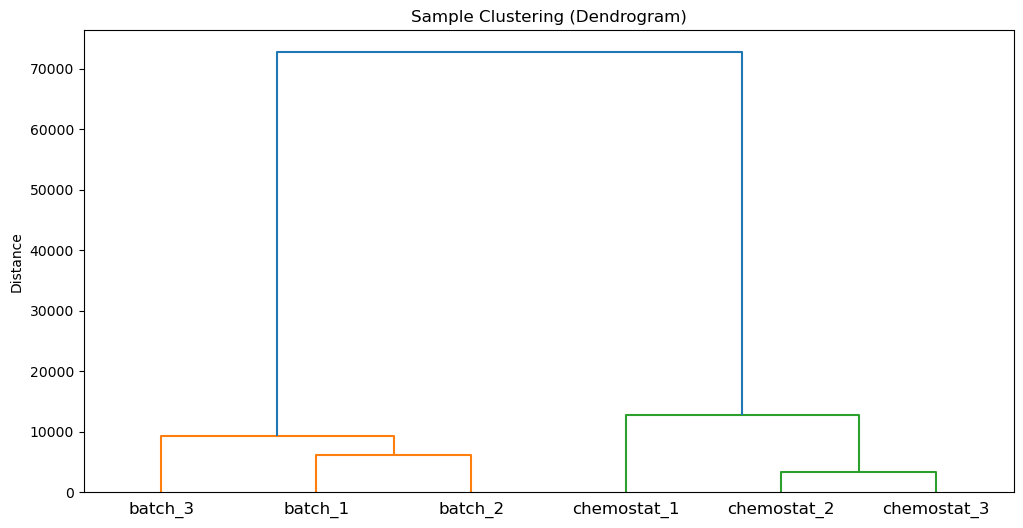

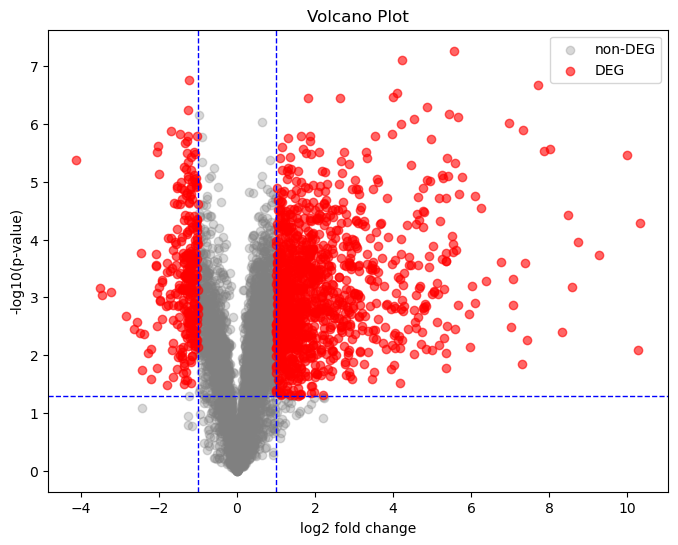

--- Top 10 Differentially Expressed Genes ---
                                                 gene    log2FC          pval  \
1162                                       catalase A  5.571445  5.406710e-08   
5926                                            Sue1p  4.231303  7.705177e-08   
4738  tubulin-binding prefolding complex subunit GIM3 -1.220444  1.764187e-07   
4543                       alcohol dehydrogenase ADH2  7.723890  2.125730e-07   
9              glutamate dehydrogenase (NADP(+)) GDH3  4.089283  2.890303e-07   
2760                                            Xbp1p  4.004069  3.359807e-07   
2431                                            Dur3p  2.632185  3.595620e-07   
839                         malate dehydrogenase MDH3  1.824598  3.595851e-07   
4313                                            Isf1p  4.875161  5.150008e-07   
4207               ribosomal 40S subunit protein S17A -1.265027  5.740160e-07   

      is_DEG  
1162    True  
5926    True  
4738    True  
45

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import ttest_ind

# --- 1. データの読み込みと前処理 ---
# GitHubからTPMデータを読み込む
df_tpm = pd.read_excel("https://github.com/iwata97/bioinfo/raw/refs/heads/main/TPM_data.xlsx")

# 数値データのみを抽出（gene列を除去）
tpm = df_tpm.drop('gene', axis=1)

# 解析用にlog2変換（0回避のため+1してから対数を取る）
log_tpm = np.log2(tpm + 1.0)

# --- 2. 階層的クラスタリング（サンプルの分類） ---
# サンプル同士を比較するため、行と列を入れ替える（転置）
tpm_t = tpm.T

# ウォード法とユークリッド距離でクラスタリング実行
linkage_result = linkage(tpm_t, method='ward', metric='euclidean')

# 樹状図（デンドログラム）の描画
plt.figure(figsize=(12, 6), dpi=100)
dendrogram(linkage_result, labels=list(tpm_t.index))
plt.title('Sample Clustering (Dendrogram)')
plt.ylabel('Distance')
plt.show()

# --- 3. 統計検定（Welchのt検定） ---
# 比較する2つのグループを分ける（例：batch群とchemostat群）
log_batch = log_tpm.iloc[:, :3]
log_chemo = log_tpm.iloc[:, 3:]

# 平均の差（log2 Fold Change）を計算
log2fc = log_chemo.mean(axis=1) - log_batch.mean(axis=1)

# 全遺伝子に対してt検定を行いp値を算出
pvals = []
for i in range(len(tpm)):
    stat, pval = ttest_ind(log_batch.iloc[i], log_chemo.iloc[i], equal_var=False)
    pvals.append(pval)

pvals = np.array(pvals)
neg_log10_pvals = -np.log10(pvals)

# --- 4. ボルケーノプロット（発現変動の可視化） ---
# 有意な遺伝子のフラグ立て（変動2倍以上 かつ p値 0.05未満）
is_DEG = (np.abs(log2fc) > 1) & (pvals < 0.05) # ここでは1(2倍)に設定

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(log2fc[~is_DEG], neg_log10_pvals[~is_DEG], color='gray', alpha=0.3, label='non-DEG')
ax.scatter(log2fc[is_DEG], neg_log10_pvals[is_DEG], color='red', alpha=0.6, label='DEG')

# しきい値のラインを描画
ax.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1)
ax.axvline(1, color='blue', linestyle='--', linewidth=1)
ax.axvline(-1, color='blue', linestyle='--', linewidth=1)

ax.set_xlabel('log2 fold change')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano Plot')
ax.legend()
plt.show()

# --- 5. 解析結果の統合と保存 ---
# 全遺伝子の結果をまとめたデータフレームを作成
results_df = df_tpm[['gene']].copy()
results_df['log2FC'] = log2fc
results_df['pval'] = pvals
results_df['is_DEG'] = is_DEG

# 有意な遺伝子（DEG）のみを抽出し、p値が小さい順に並べ替え
deg_df = results_df[results_df['is_DEG']].sort_values(by='pval')

# 上位を表示
print("--- Top 10 Differentially Expressed Genes ---")
print(deg_df.head(10))

# 結果をCSVファイルに書き出し
deg_df.to_csv("Analysis_Results_DEG.csv", index=False)
print("\nSuccess: Results saved to 'Analysis_Results_DEG.csv'")